In [40]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()

print(X_train.shape, X_val.shape)

(1032064, 17) (258017, 17)


In [41]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=8.96,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.40901
[50]	validation_0-aucpr:0.43022
[100]	validation_0-aucpr:0.43281
[150]	validation_0-aucpr:0.43286
[200]	validation_0-aucpr:0.43339
[250]	validation_0-aucpr:0.43319
[299]	validation_0-aucpr:0.43323


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


PR-AUC:0.4332

              precision    recall  f1-score   support

      Normal       1.00      0.77      0.87    232109
      Fraude       0.32      1.00      0.49     25908

    accuracy                           0.79    258017
   macro avg       0.66      0.88      0.68    258017
weighted avg       0.93      0.79      0.83    258017



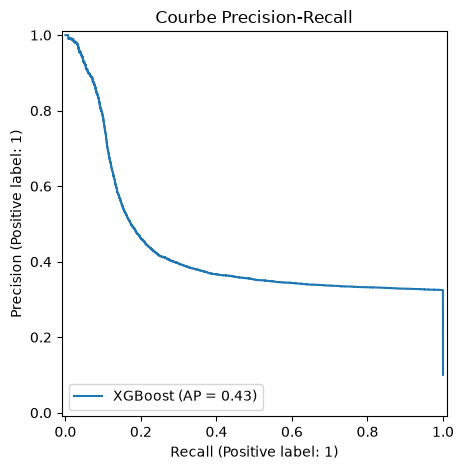

In [42]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, PrecisionRecallDisplay
)

y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

pr_auc  = average_precision_score(y_val, y_pred_proba)

print(f"PR-AUC:{pr_auc:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=['Normal', 'Fraude']))


PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba, name="XGBoost")
plt.title("Courbe Precision-Recall")
plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    report = classification_report(y_val, y_pred_t, target_names=['Normal', 'Fraude'], output_dict=True)
    fraude = report['Fraude']
    print(f"Seuil {t} precision={fraude['precision']:.2f}  recall={fraude['recall']:.2f}  f1={fraude['f1-score']:.2f}")

Seuil 0.1 precision=0.32  recall=1.00  f1=0.49
Seuil 0.2 precision=0.32  recall=1.00  f1=0.49
Seuil 0.3 precision=0.32  recall=1.00  f1=0.49
Seuil 0.4 precision=0.32  recall=1.00  f1=0.49
Seuil 0.5 precision=0.32  recall=1.00  f1=0.49
Seuil 0.6 precision=0.32  recall=1.00  f1=0.49
Seuil 0.7 precision=0.32  recall=1.00  f1=0.49


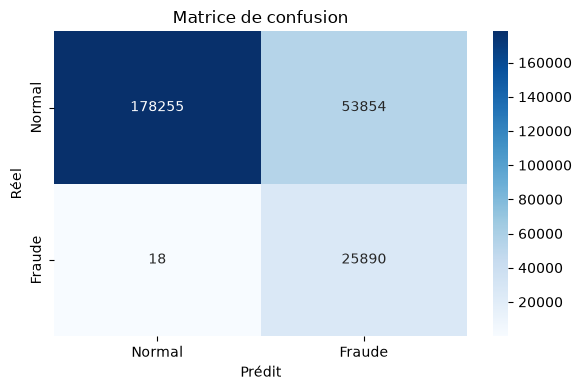

In [44]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

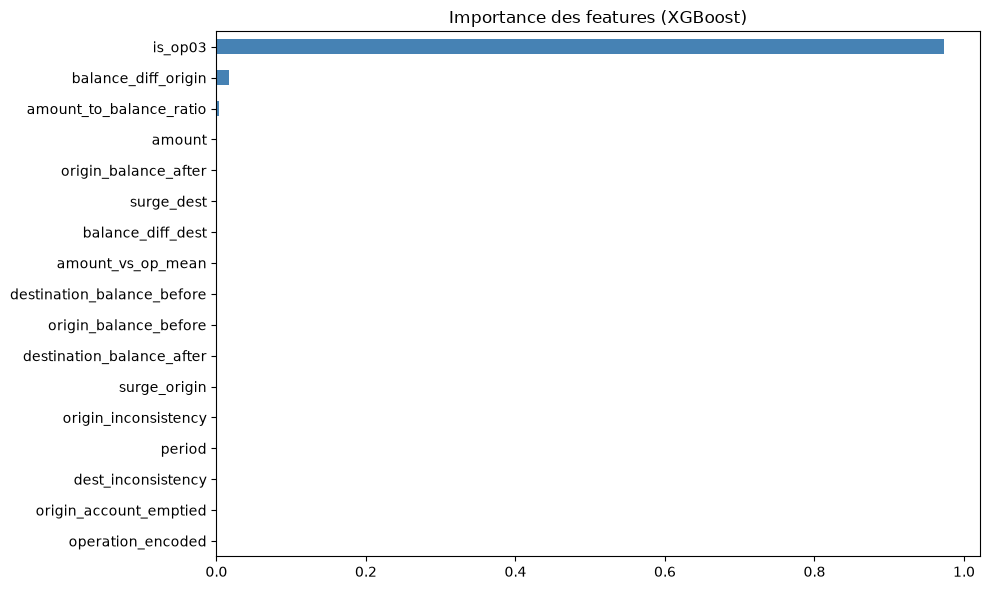

In [45]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Importance des features (XGBoost)')
plt.tight_layout()
plt.show()

In [46]:
df_test = pd.read_csv("../data/raw/test.csv")

df_test['balance_diff_origin'] = df_test['origin_balance_after'] - df_test['origin_balance_before']
df_test['balance_diff_dest'] = df_test['destination_balance_after'] - df_test['destination_balance_before']

df_test['origin_inconsistency'] = abs(
    (df_test['origin_balance_before'] - df_test['amount']) - df_test['origin_balance_after']
)
df_test['dest_inconsistency'] = abs(
    (df_test['destination_balance_before'] + df_test['amount']) - df_test['destination_balance_after']
)

df_test['origin_account_emptied']  = (df_test['origin_balance_after'] == 0).astype(int)
df_test['amount_to_balance_ratio'] = df_test['amount'] / (df_test['origin_balance_before'] + 1)
df_test['is_op03'] = (df_test['operation'] == 'op_03').astype(int)

operation_mapping = {'op_05': 0, 'op_03': 1, 'op_04': 2, 'op_02': 3, 'op_01': 4}
df_test['operation_encoded'] = df_test['operation'].map(operation_mapping)
df_test['surge_origin'] = df_test.groupby(['origin_account', 'period'])['id'].transform('count')
df_test['surge_dest']   = df_test.groupby(['destination_account', 'period'])['id'].transform('count')
amount_mean_test = df_test.groupby('operation')['amount'].transform('mean')
df_test['amount_vs_op_mean'] = df_test['amount'] / (amount_mean_test + 1)

features = [
    'period', 'amount', 'is_op03', 'operation_encoded',
    'origin_balance_before', 'origin_balance_after',
    'destination_balance_before', 'destination_balance_after',
    'balance_diff_origin', 'balance_diff_dest',
    'origin_inconsistency', 'dest_inconsistency',
    'origin_account_emptied', 'amount_to_balance_ratio',
    'surge_origin', 'surge_dest','amount_vs_op_mean',
]

X_test = df_test[features]
print(X_test.shape)

(430100, 17)


In [47]:
test_proba = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'target': test_proba
})

submission.to_csv("../submissions/submission_xgb_v1.csv", index=False)
print(submission.head(10))
print(f"\nFichier sauvegardé : {submission.shape[0]} lignes")

                     id    target
0  dtf_0000001_08a8a524  0.000002
1  dtf_0000002_ae0d3769  0.789254
2  dtf_0000003_843bab7c  0.789485
3  dtf_0000004_91643844  0.000002
4  dtf_0000005_17bd9a08  0.785474
5  dtf_0000006_252a6318  0.000002
6  dtf_0000007_52b0ffae  0.000002
7  dtf_0000008_c37743d9  0.000002
8  dtf_0000009_bff3cf50  0.786389
9  dtf_0000010_7f815b93  0.787148

Fichier sauvegardé : 430100 lignes
